In [1]:
import numpy as np
import torch

## Satellite Example

In [2]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

dtype = torch.float64
device= "cpu"
bounds  = torch.tensor([[0., 0., 0., 0., 0.], 
                        [2., 2., 2., 2., 2.]], dtype=dtype, device=device) # always a 2 x d tensor
x_input = unnormalize(torch.rand(10,5), bounds=bounds)

for i in range(0,20):
    print('Run',i+1,"\r")
    filename = "hist_rep_" + str(i+1) + ".pt"
    # bounds  = torch.tensor([[0., 0., 0., 0., 0.], 
    #                         [2., 2., 2., 2., 2.]], dtype=dtype, device=device) # always a 2 x d tensor
    # x_input = unnormalize(torch.rand(10,5), bounds=bounds)
    
    sat_prob = Satellite()
    gpmodel = train_multitask_gp(sat_prob, num_train=10, seed=1111+i) 
    active_learning_loop(gpmodel,acq_method = 'entropy', maxiters = 30, 
                         disp = True, save_hist = (x_input, filename, 'openmdao'), 
                         log_hyperparams = False)

## Review comment
# It looks like OpenMDAO is called internally to compute the true fixed point. Please make this
# optional and add a flag as a kwarg to turn this on if necessary (default should be off)

Run 1 


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1753839225953\work\torch\csrc\utils\tensor_new.cpp:656.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 2 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 3 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 4 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 30
done
Run 5 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 6 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 7 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 8 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done
Run 9 
Iter 1
I

Text(0, 0.5, 'distance from openMDAO result')

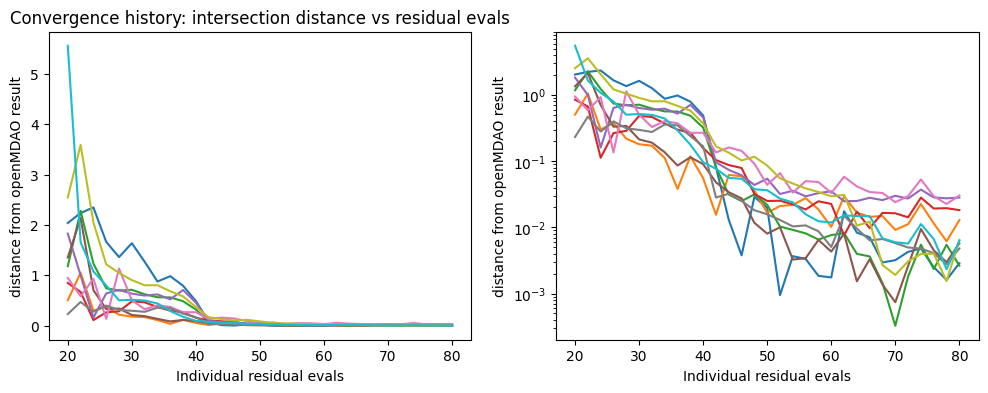

In [5]:
import torch
import matplotlib.pyplot as plt

history = torch.load("hist_rep_2.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

Text(0, 0.5, 'distance from openMDAO result')

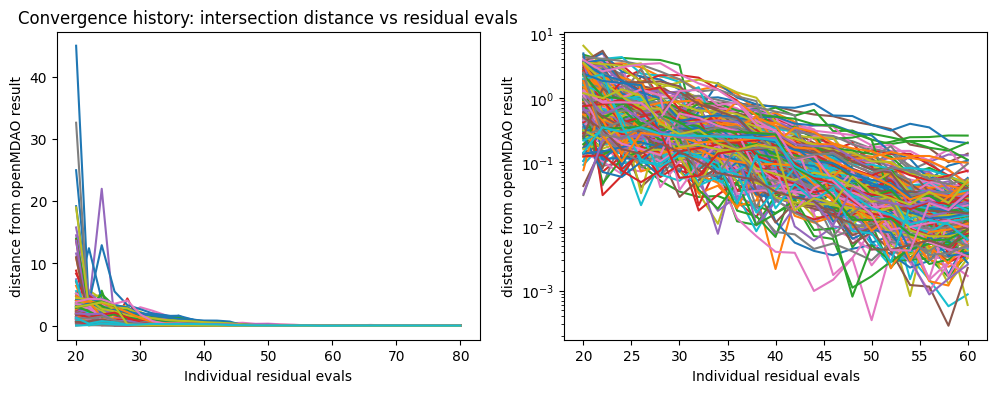

In [6]:
import torch
import matplotlib.pyplot as plt

# history = torch.load("hist_1.pt")
# num_evals = history["num_evals"]
# dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
for i in range(0,20):
    history = torch.load("hist_rep_" + str(i+1) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
for i in range(0,20):
    history = torch.load("hist_" + str(i+1) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

torch.Size([31, 10, 20])


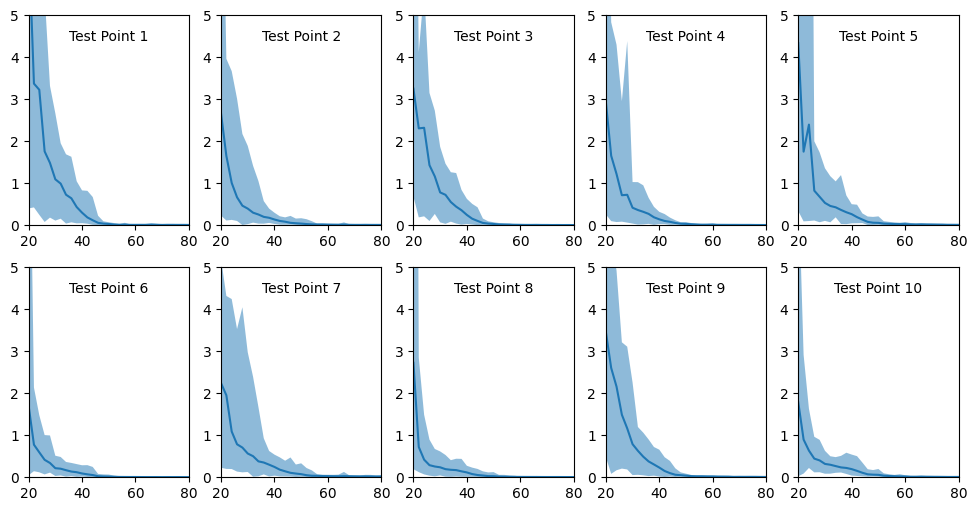

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

num_points = 10
num_runs = 20

# Collate results for all points.
for i in range(0,num_runs):
    filename = "hist_rep_" + str(i+1) + ".pt"
    history = torch.load(filename)
    # num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    if i==0:
        # Initialize history
        # Assume number of evals is the same for all
        num_evals = history["num_evals"]
        dist_history_all = dist_history
    else:
        # Stack all runs into one 3D tensor.
        # Row = iteration count
        # Column = test point index
        # Depth = training run index
        dist_history_all = torch.dstack((dist_history_all,
                                         dist_history))

print(dist_history_all.shape)

# Plot for each point.
fig = plt.figure(figsize=(12,6))

for i in range(0,num_points):
    ax = fig.add_subplot(2,5,i+1)
    dist_history = dist_history_all[:,i,:] # Get slice corresponding to point
    
    # fig = plt.figure(figsize=(12,4))
    ax.plot(num_evals, dist_history.mean(1))
    ax.fill_between(num_evals, dist_history.max(1).values, dist_history.min(1).values, 
                     alpha=0.5)
    ax.set_xlim((20,80))
    ax.set_ylim((0,5))
    ax.text(0.5, 0.88,
            'Test Point ' + str(i+1),
            horizontalalignment='center',
            transform=ax.transAxes)
    
# plt.show();
plt.savefig("satellite_convergence_mean.png");

In [2]:
## Review comment
# Please avoid hardcoding!


import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[1,...]) # use input from above
input_vec = torch.rand(5)*2 # random input
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,0])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,1])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

NameError: name 'gpmodel' is not defined

## Aerostructural Example

In [1]:
import numpy as np
import torch

In [2]:
from test_functions import Aerostructures
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

dtype = torch.float64
device= "cpu"
bounds  = torch.tensor([[0.  ],
                        [300.]], dtype=dtype, device=device) # always a 2 x d tensor
# x_input = unnormalize(torch.rand(10,1), bounds=bounds)
x_input = unnormalize(torch.linspace(1e-4,1,10).reshape(-1,1), bounds=bounds)

for i in range(0,20):
    print('Run',i+1,"\r")
    filename = "aero_hist_rep_" + str(i+1) + ".pt"

    prob = Aerostructures()
    gpmodel = train_multitask_gp(prob, num_train=10, seed=1111+i) 
    active_learning_loop(gpmodel, acq_method = 'entropy', maxiters = 80, 
                         disp = True, save_hist = (x_input, filename, 'openmdao'), 
                         log_hyperparams = True, rep_count=i)


Run 1 


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\linear_operator\utils\interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\bld\libtorch_1753839225953\work\torch\csrc\utils\tensor_new.cpp:656.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
Iter 41
Iter 42
Iter 43
Iter 44
Iter 45
Iter 46
Iter 47
Iter 48
Iter 49
Iter 50
Iter 51
Iter 52
Iter 53
Iter 54
Iter 55
Iter 56
Iter 57
Iter 58
Iter 59
Iter 60
Iter 61
Iter 62
Iter 63
Iter 64
Iter 65
Iter 66
Iter 67
Iter 68
Iter 69
Iter 70
Iter 71
Iter 72
Iter 73
Iter 74
Iter 75
Iter 76
Iter 77
Iter 78
Iter 79
Iter 80
done
Run 2 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
Iter 41
Iter 42
Iter 43
Iter 44
Iter 45
Iter 4

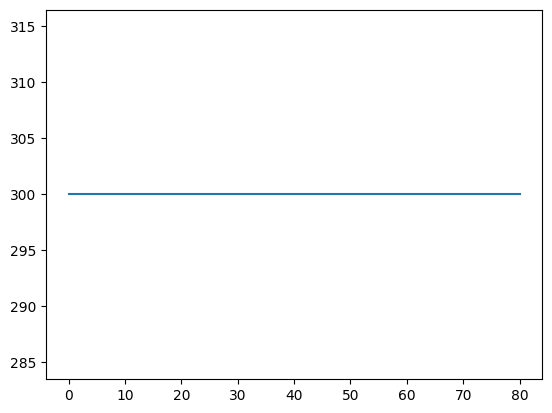

In [4]:
dog = torch.load('aero_hist_rep_1.pt')
int_history = dog['intersection_history'].reshape(81,10,3).transpose(0,1)
# int_history[0,:,0]
import matplotlib.pyplot as plt
plt.plot(int_history[9,:,0])

Text(0, 0.5, 'distance from openMDAO result')

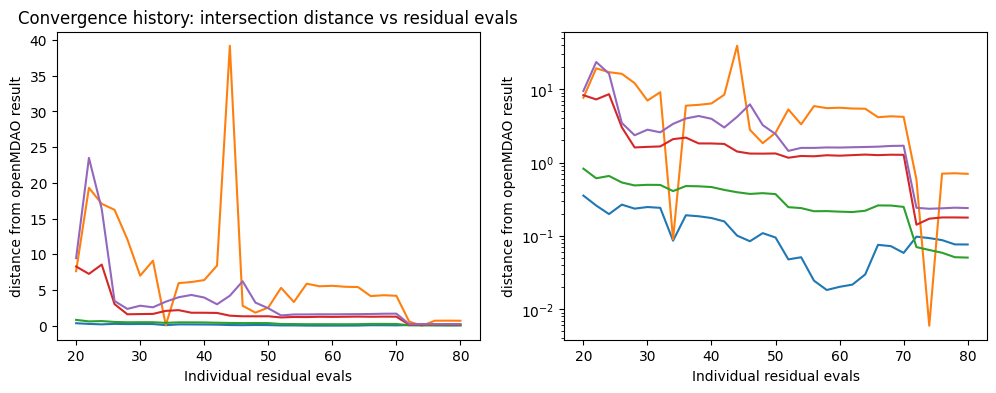

In [3]:
import torch
import matplotlib.pyplot as plt

history = torch.load("hist_aero.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

C:\Users\kaily\AppData\Local\Temp\ipykernel_60140\2571187104.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dist_history = np.minimum.accumulate(dist_history)


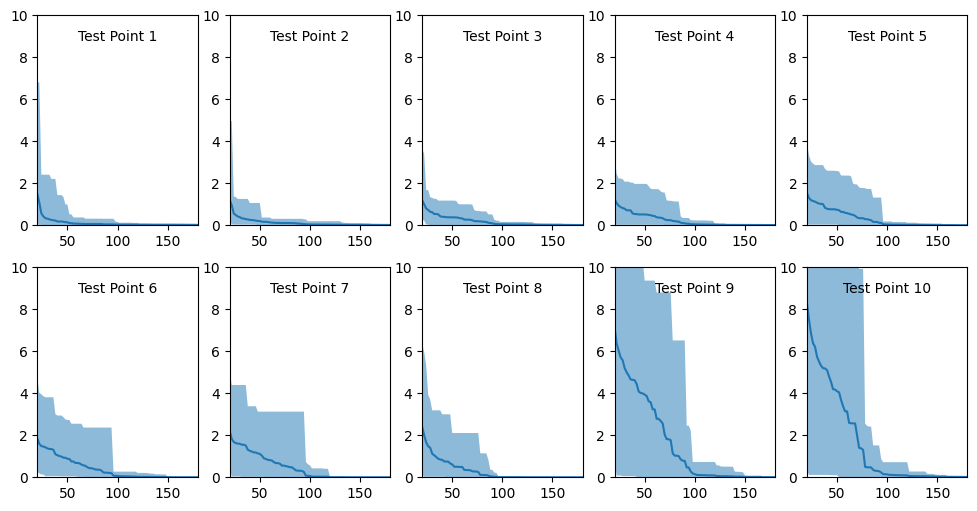

In [64]:
import torch
import numpy as np
import matplotlib.pyplot as plt

num_points = 10
num_runs = 20

# Collate results for all points.
for i in range(0,20):
    filename = "aero_hist_rep_" + str(i+1) + ".pt"
    history = torch.load(filename)
    # num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    dist_history = np.minimum.accumulate(dist_history)
    # print(dist_history[:,9])
    if i==0:
        # Initialize history
        # Assume number of evals is the same for all
        num_evals = history["num_evals"]
        dist_history_all = dist_history
    else:
        # Stack all runs into one 3D tensor.
        # Row = iteration count
        # Column = test point index
        # Depth = training run index
        dist_history_all = torch.dstack((dist_history_all,
                                         dist_history))

# print(dist_history_all.shape)

# Plot for each point.
fig = plt.figure(figsize=(12,6))

for i in range(0,num_points):
    ax = fig.add_subplot(2,5,i+1)
    dist_history = dist_history_all[:,i,:] # Get slice corresponding to point
    
    # fig = plt.figure(figsize=(12,4))
    ax.plot(num_evals, dist_history.mean(1))
    # print(dist_history.max(1).values)
    # ax.plot(num_evals, dist_history.max(1).values)
    ax.fill_between(num_evals, dist_history.max(1).values, dist_history.min(1).values, 
                     alpha=0.5)
    ax.set_xlim((20,max(num_evals)))
    ax.set_ylim((0,10))
    ax.text(0.5, 0.88,
            'Test Point ' + str(i+1),
            horizontalalignment='center',
            transform=ax.transAxes)

# plt.tight_layout()
    
# plt.show();
plt.savefig("aerostrux_convergence_mean.png");



In [62]:
# for i in range(0,20):
#     print('it' + str(i+1))
#     history = torch.load('aero_hist_rep_' + str(i+1) + '.pt')
#     dist_history = history['dist_history']
#     plt.plot(dist_history[:,8].reshape(-1,1))
#     plt.ylim((0,20))
#     plt.show()

iter 71


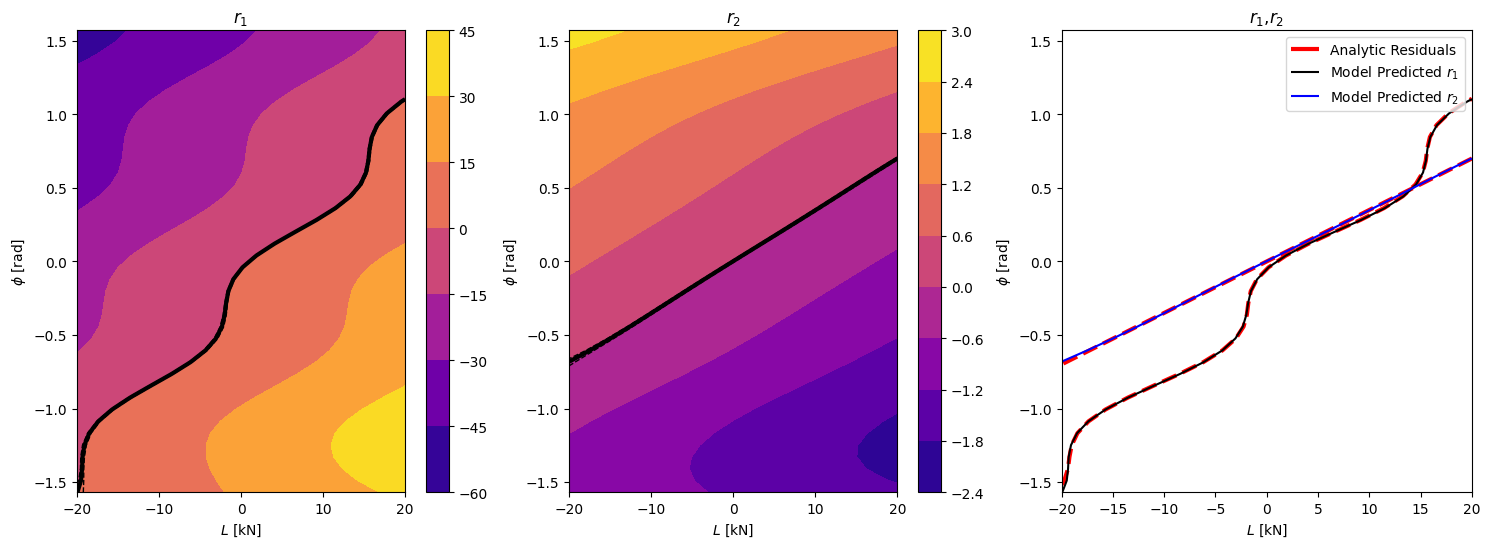

iter 72


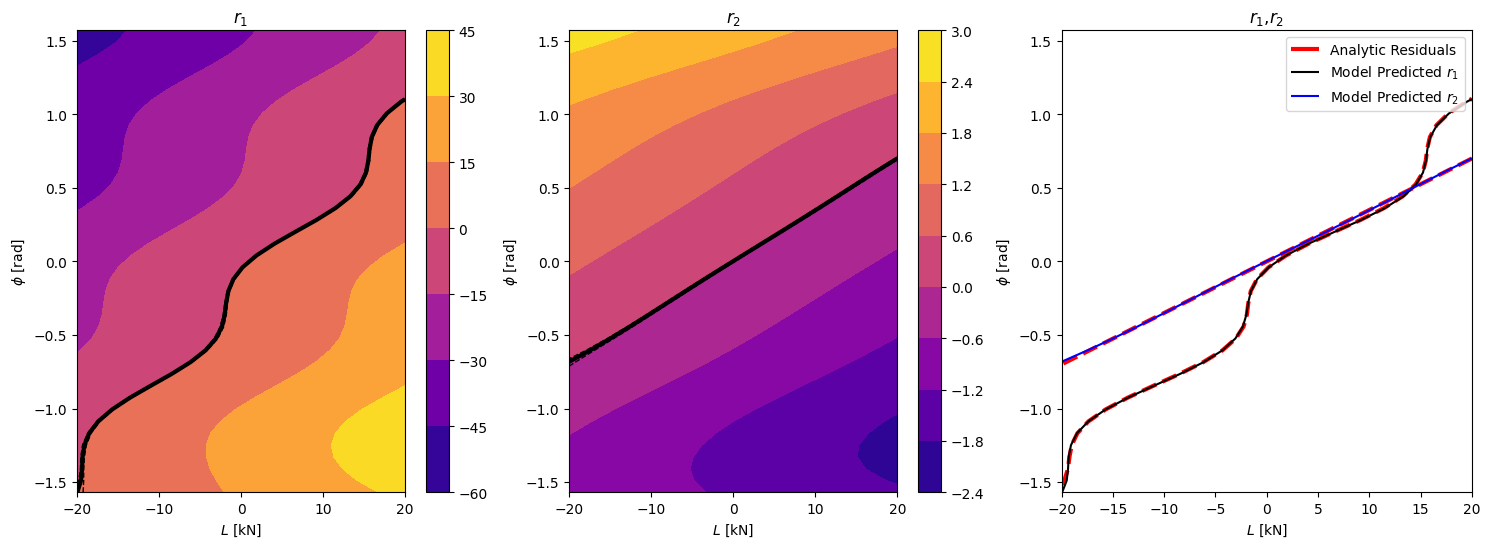

iter 73


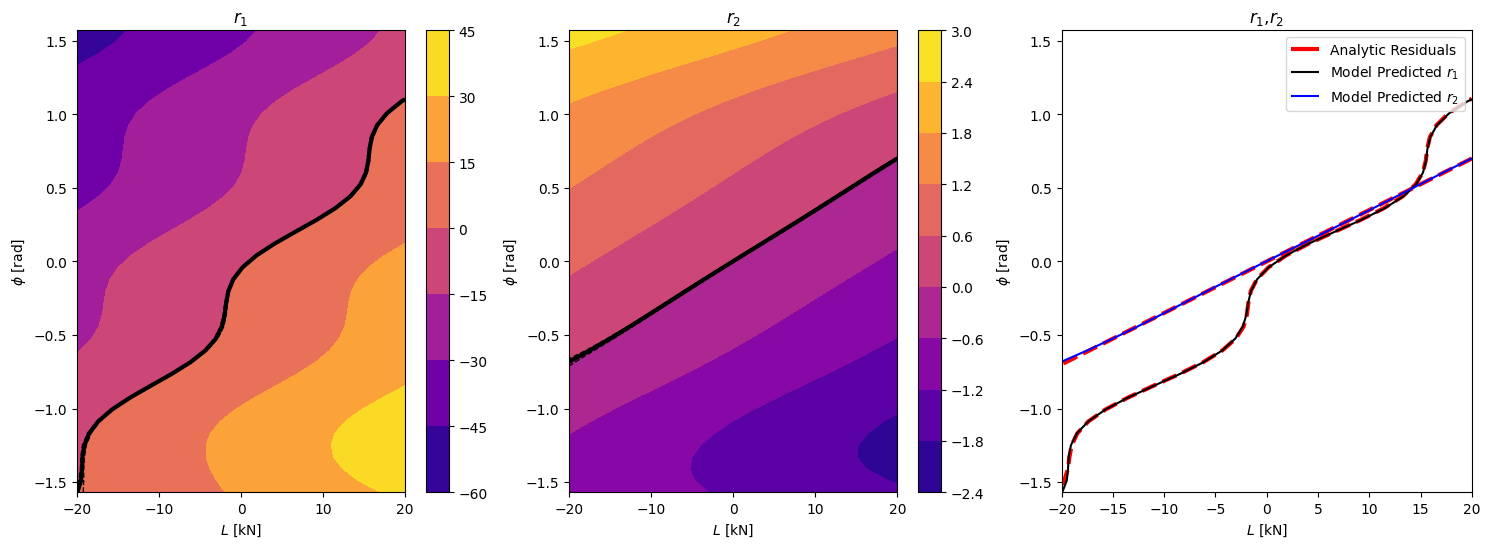

iter 74


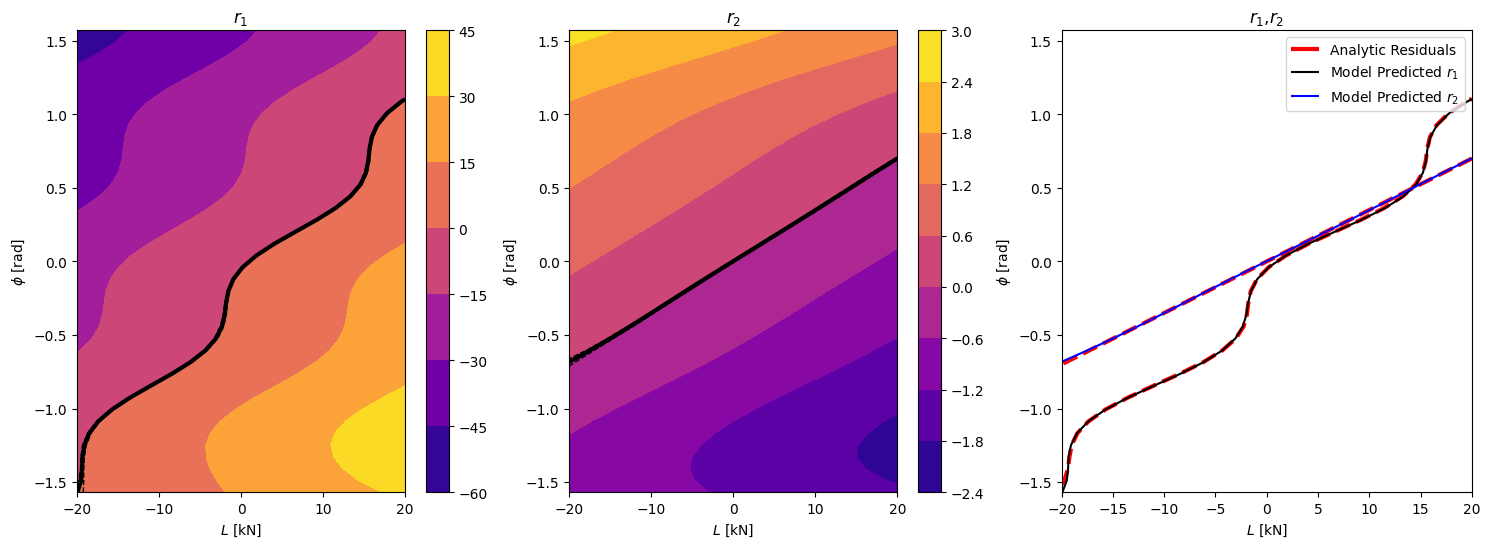

iter 75


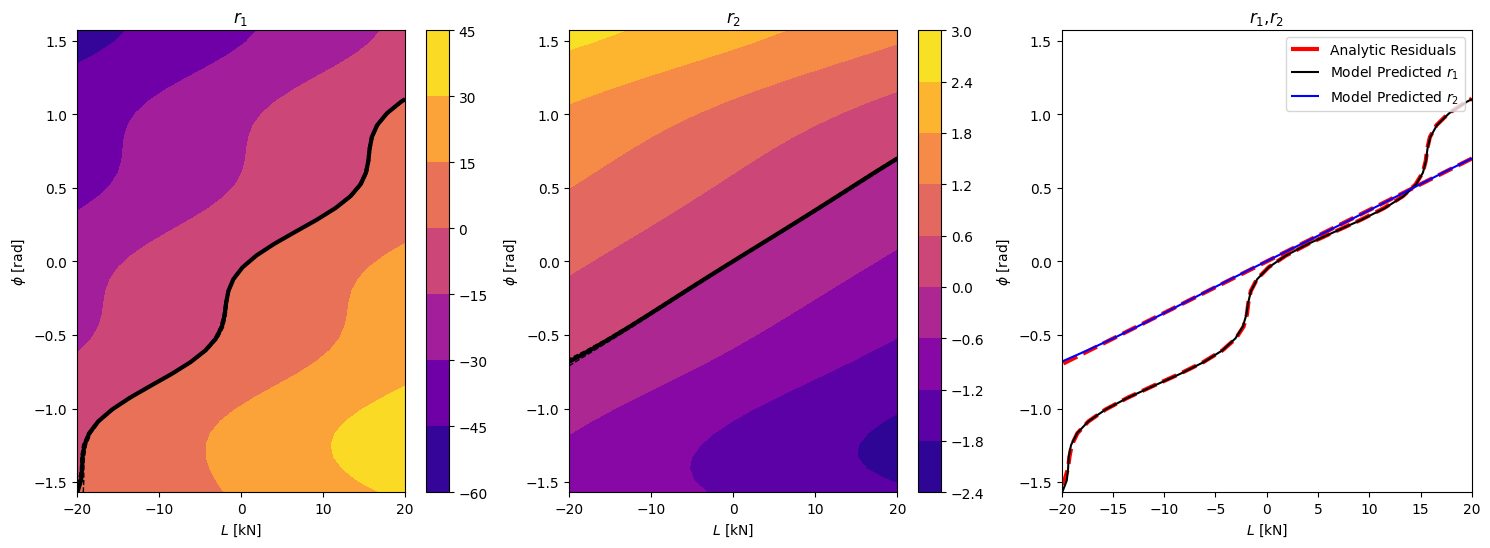

iter 76


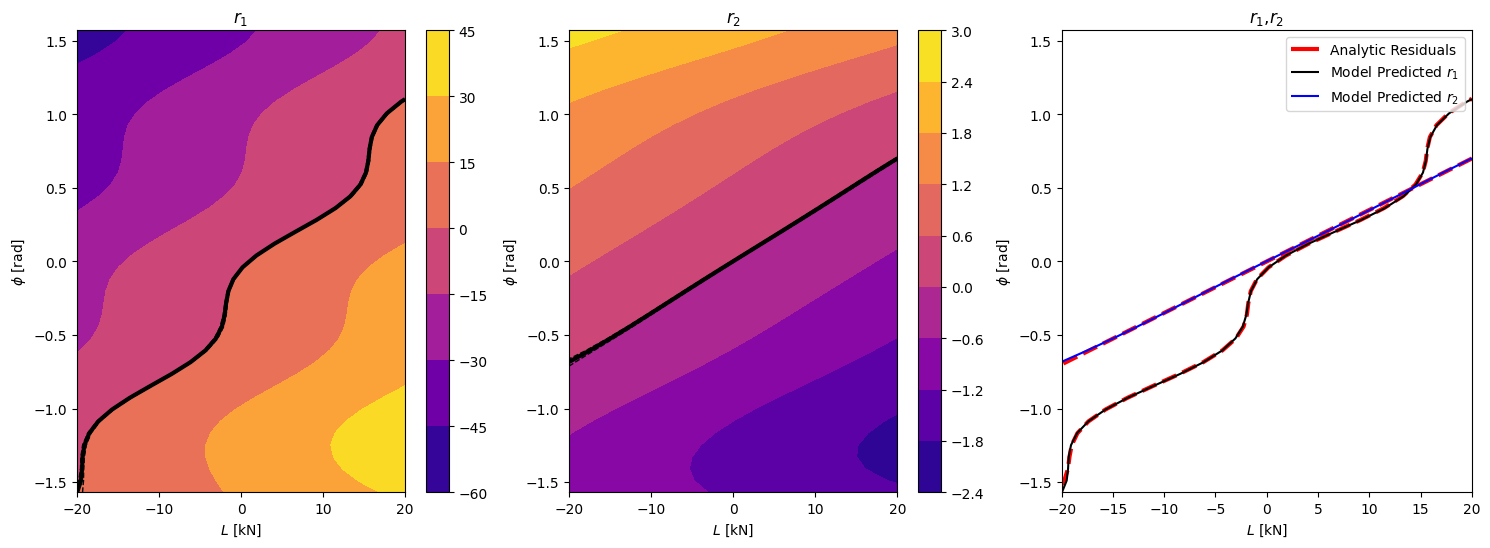

iter 77


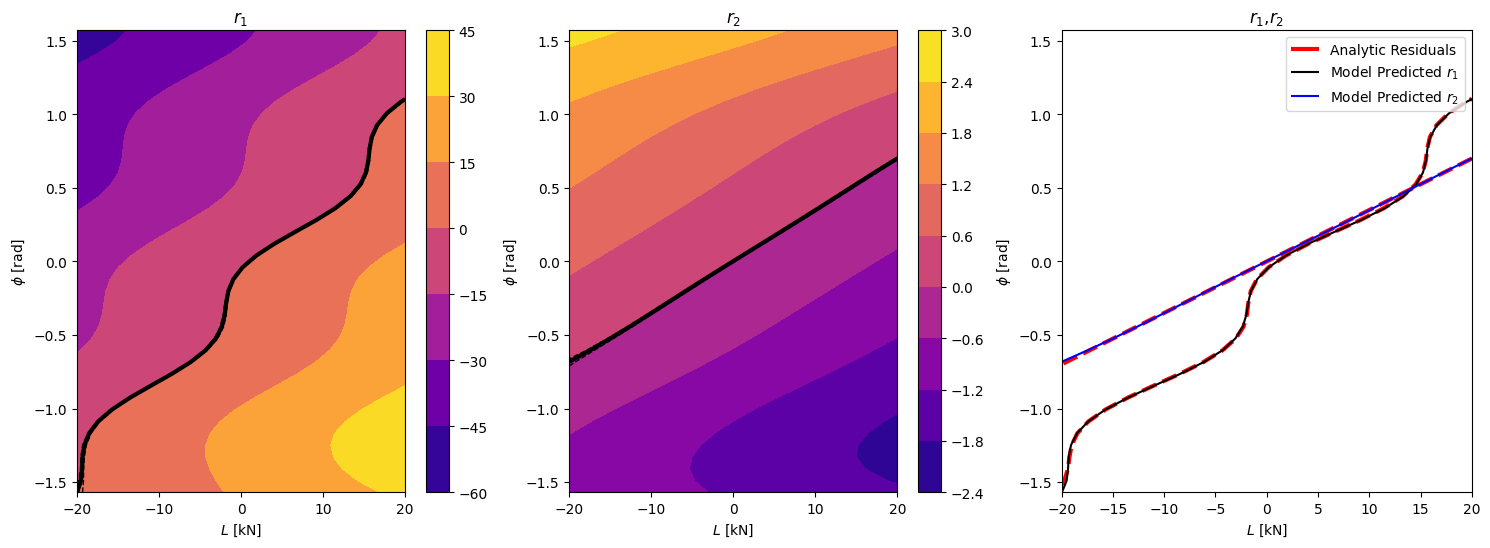

iter 78


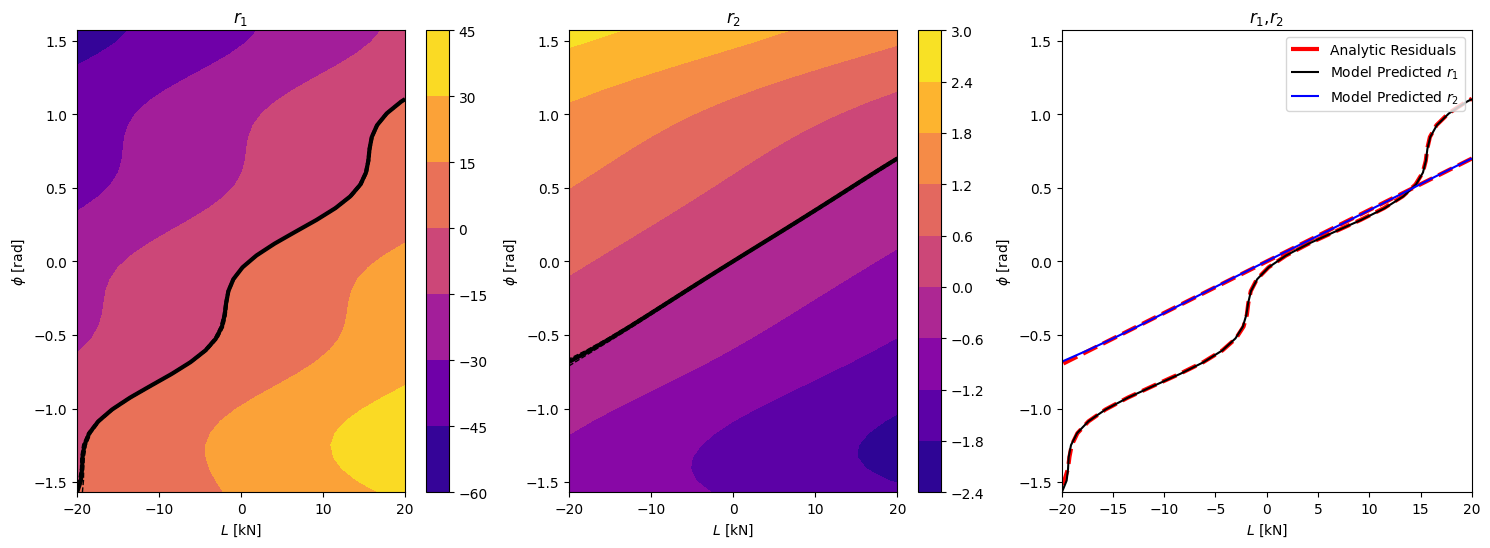

iter 79


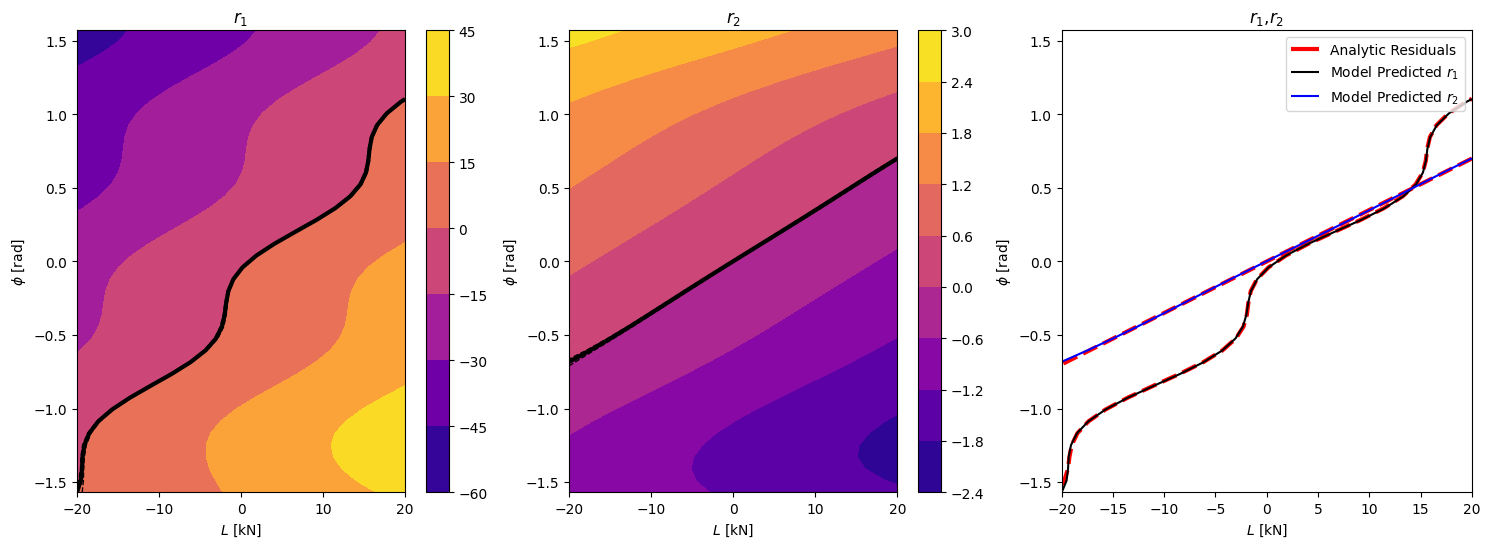

iter 80


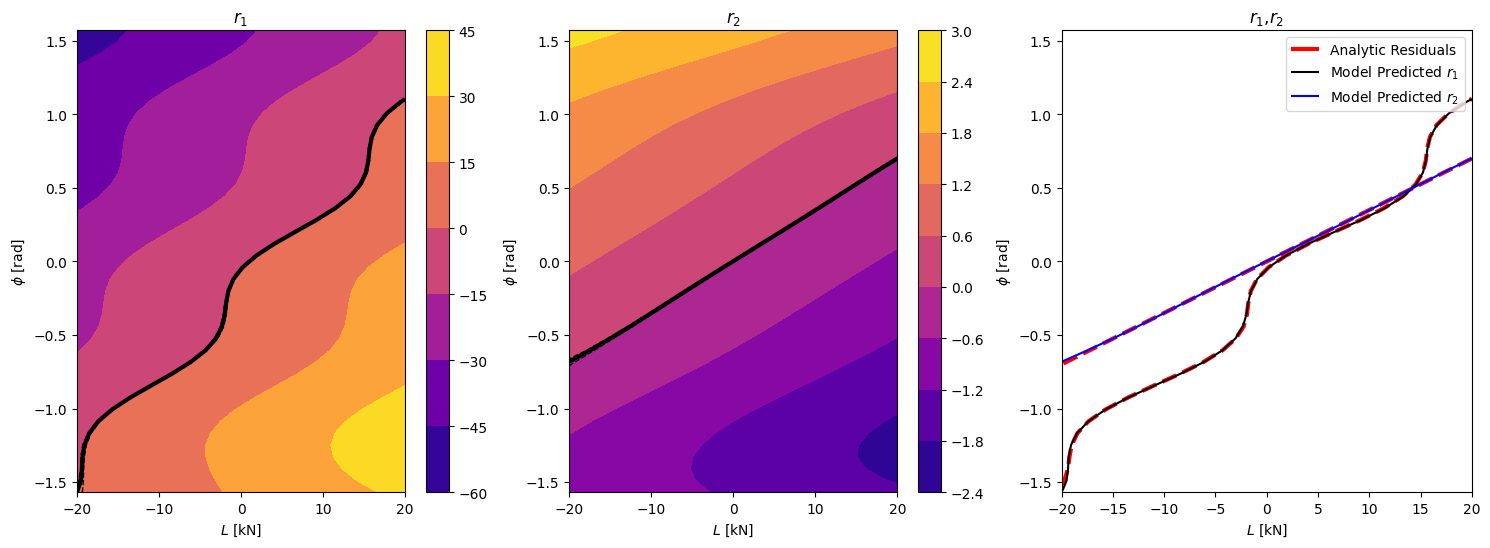

In [33]:
import torch
from utils import unstandardize

input_vec = x_input[8]
trial = 5

# Unpack result
mt_model = gpmodel.model
# y = gpmodel.train_y
bounds = prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = prob.res[:,0]
r2vec = prob.res[:,1]



for it in range(70,80):
    # print('iter ' + str(20+2*it))
    print('iter ' + str(it+1))
    
    # load model
    dir_name = 'log'
    snapshot = torch.load(dir_name + '/' + 'model_run_' + str(trial) + '_iter_' + str(it+1) + '.pt', weights_only = False)
    model_snapshot = snapshot["model"]
    y = snapshot["train_y"]
    
    # make predictions
    # npts = 40
    
    # Predictions
    test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                                 xvec.reshape(-1,1),
                                 yvec.reshape(-1,1)])
    test_x = normalize(test_x,bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
    
    prediction1 = unstandardize(model_snapshot.likelihood(model_snapshot(test_x1)), y[:,0])
    prediction2 = unstandardize(model_snapshot.likelihood(model_snapshot(test_x2)), y[:,1])

    fig = plt.figure(figsize=(18,6))

    # plot
    # r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax1 = fig.add_subplot(131)
    cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                      cmap = 'plasma')
    ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
                levels=[0.], 
                linestyles='-', linewidths=3, colors='k')
    ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    # ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
    fig.colorbar(cf1)
    ax1.set_title(r'$r_1$')
    ax1.set_xlabel(r'$L$ [kN]')
    ax1.set_ylabel(r'$\phi$ [rad]')
    
    
    
    # r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax2 = fig.add_subplot(132)
    cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                      cmap = 'plasma')
    ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
                levels=[0.], 
                linestyles='-', linewidths=3, colors='k')
    ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    # ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
    fig.colorbar(cf2)
    ax2.set_title(r'$r_2$')
    ax2.set_xlabel(r'$L$ [kN]')
    ax2.set_ylabel(r'$\phi$ [rad]')
    
    
    
    # both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax3 = fig.add_subplot(133)
    # cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
    #              cmap = 'plasma')
    # fig.colorbar(cf3)
    s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
                levels=[0.],
                linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles='--', linewidths=3, colors='r')
    s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='b')
    s3_artist,_ = s3.legend_elements()
    ax3.set_title(r'$r_1$,$r_2$')
    ax3.set_xlabel(r'$L$ [kN]')
    ax3.set_ylabel(r'$\phi$ [rad]')
    #ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
    ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

    plt.show()

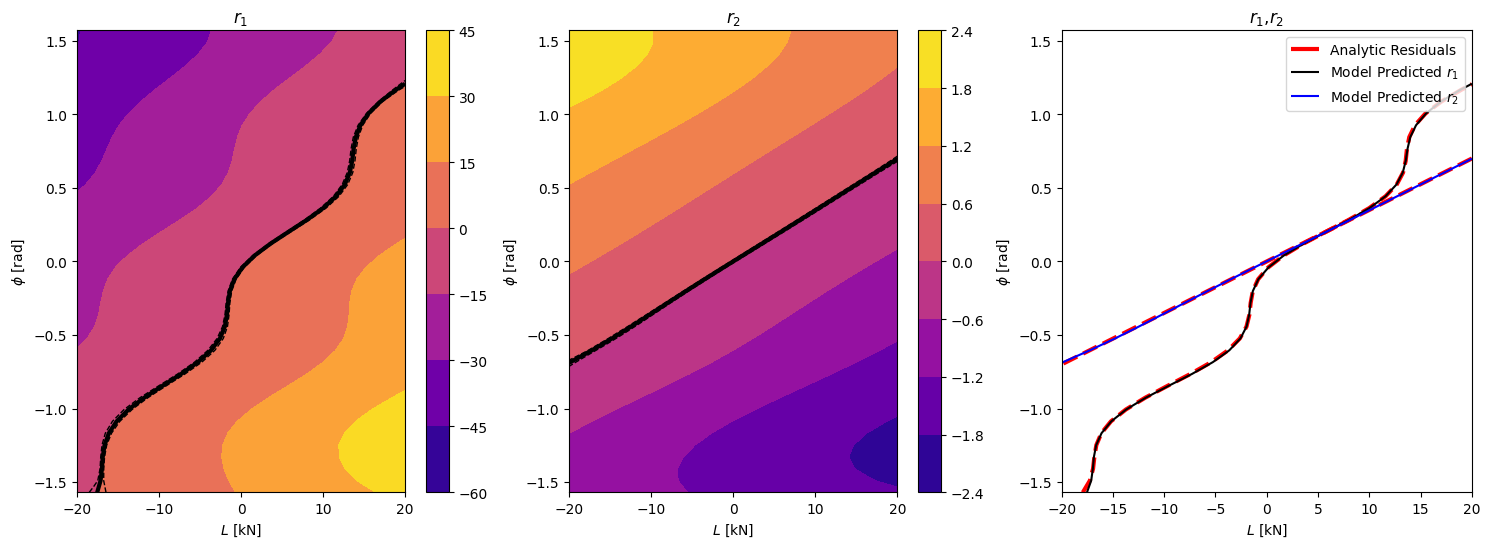

In [50]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([233])
# input_vec = torch.rand(5)*2
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = prob.res[:,0]
r2vec = prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,0])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,1])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$L$ [kN]')
ax1.set_ylabel(r'$\phi$ [rad]')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$L$ [kN]')
ax2.set_ylabel(r'$\phi$ [rad]')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$L$ [kN]')
ax3.set_ylabel(r'$\phi$ [rad]')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

## Multiple runs

In [ ]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

x_input = torch.rand(10,5)*2
# 
for i in range(0,20):
    print("hist"+str(i))
    filename = "hist" + str(i) + ".pt"
    sat_prob = Satellite()
    result = train_multitask_gp(sat_prob, num_train=10, seed=1111)
    active_learning_loop(result,
                         acq_method = 'entropy', 
                         maxiters = 30, disp = True, 
                         save_hist = (x_input, filename))



In [ ]:
import torch
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,3))
host = fig.add_subplot(111)

for i in range(0,20):
    history = torch.load("hist" + str(i) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"]

    plt.plot(num_evals, dist_history)

# plt.axvline(x=40, color='red', linestyle='--', label="NLBGS Converged"

host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('Distance from OpenMDAO result')

## Note: intersection distance converging to values larger than about 1E-2 indiciates that the intersection point occurs outside the bounds of the problem. This needs to be addressed. For example:

In [ ]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = result.model
y = result.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([0.4074, 0.5940, 0.8677, 0.3936, 0.0059])
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y)
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y)

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

In [41]:
from botorch.utils.transforms import standardize
from utils import unstandardize

test = torch.tensor([[-0.4777, -0.2158],
        [ 0.0608,  0.9787],
        [ 0.2262, -0.0768],
        [ 0.5601, -0.9951],
        [ 0.5964,  0.6110]])
print(test)
test = test + torch.tensor([0,10000]).repeat(5,1)
print(test)
print(test.mean(0))
print(standardize(test))
print(standardize(test).mean(0))

tensor([[-0.4777, -0.2158],
        [ 0.0608,  0.9787],
        [ 0.2262, -0.0768],
        [ 0.5601, -0.9951],
        [ 0.5964,  0.6110]])
tensor([[-4.7770e-01,  9.9998e+03],
        [ 6.0800e-02,  1.0001e+04],
        [ 2.2620e-01,  9.9999e+03],
        [ 5.6010e-01,  9.9990e+03],
        [ 5.9640e-01,  1.0001e+04]])
tensor([1.9316e-01, 1.0000e+04])
tensor([[-1.5331, -0.3601],
        [-0.3025,  1.1962],
        [ 0.0755, -0.1794],
        [ 0.8386, -1.3756],
        [ 0.9215,  0.7177]])
tensor([ 1.1921e-08, -2.5449e-04])


In [39]:
standardize(test).mean(0)

tensor([ 1.1921e-08, -2.5449e-04])

In [45]:
test.numel()

10

In [47]:
test = torch.tensor([[1,2],[3,4]])
torch.diagonal(test)

tensor([1, 4])

In [74]:
test = torch.tensor([[1,2,3,4],[5,6,7,8]]).repeat(10,1)
# print(test)
tens=test.split(10)
dog = torch.rand(2,4)
print(dog)
print(*tens)
print(torch.hstack(tens))

tensor([[0.0919, 0.2930, 0.8702, 0.1519],
        [0.1507, 0.0348, 0.2431, 0.9615]])
tensor([[1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8]]) tensor([[1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8],
        [1, 2, 3, 4],
        [5, 6, 7, 8]])
tensor([[1, 2, 3, 4, 1, 2, 3, 4],
        [5, 6, 7, 8, 5, 6, 7, 8],
        [1, 2, 3, 4, 1, 2, 3, 4],
        [5, 6, 7, 8, 5, 6, 7, 8],
        [1, 2, 3, 4, 1, 2, 3, 4],
        [5, 6, 7, 8, 5, 6, 7, 8],
        [1, 2, 3, 4, 1, 2, 3, 4],
        [5, 6, 7, 8, 5, 6, 7, 8],
        [1, 2, 3, 4, 1, 2, 3, 4],
        [5, 6, 7, 8, 5, 6, 7, 8]])


In [65]:
len(prob.tasks)

2

In [66]:
len(torch.rand(10,3))

10

In [75]:
dog = torch.tensor([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
dog.reshape(1,-1)
print(dog)

tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12]])
